# LLM Augmenté

In [27]:
from langchain_openai import ChatOpenAI

In [28]:
from IPython.display import Image, display

In [29]:
from msgpack import os

In [30]:
os.environ["OPENAI_BASE_URL"] = "http://127.0.0.1:1234/v1"
os.environ["OPENAI_API_KEY"] = "lm_studio"

In [31]:
# instance de llm
llm = ChatOpenAI(model="google/gemma-4-e4b")

In [32]:
from pydantic import BaseModel, Field

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Requête qui optimise les recherches Web")
    justification: str = Field(None, description="Pourquoi cette requête est elle importante pour la demande de l'utilisateur")

# On attache notre structure de sortie au LLM
structured_llm = llm.with_structured_output(SearchQuery)
# Lancer notre llm augmente
output : SearchQuery = structured_llm.invoke("Comment faire un bon repas à base d'avocat")

print(output.search_query)
print(output.justification)

idée de recettes à l'avocat
Pour répondre de manière complète et utile, il est préférable de proposer des idées variées (déjeuner, dîner, collation) plutôt que de se concentrer sur un seul type de repas. L'ajout d'une recherche de recettes aidera à diversifier les suggestions pour le lecteur.


# Pattern 1 : Prompt Chaining

)Lorsque chaque appel de LLM traite la sortie du LLM précédent

- Prendre un topic, LLM va générer une blague, vérifier si la blague est comique, l'améliorer deux foix

In [33]:
from langgraph.graph import END, START, StateGraph

In [34]:
from typing_extensions import TypedDict, cast

class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

# Noeuds
def generate_joke(state: State) -> State:
    """Premier appel LLM pour générer une blague"""
    msg = llm.invoke(f"Ecris une courte blague sur {state["topic"]}")
    state["joke"] = f"{msg.content}"
    return state

def check_punchline(state: State) -> str:
    """Fonction pour verifier si la blague a une punchline"""
    # si la blague contient "?" ou "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"

def improve_joke(state: State) -> State:
    """Deuxieme appel du LLM pour ameliorer la blague"""
    msg = llm.invoke(f"Rend la blague plus amusante en ajoutant des jeux de mots: {state["joke"]}")
    state["improved_joke"] = f"{msg.content}"
    return state

def polish_joke(state: State) -> State:
    """Troisieme appel de LLM pour la blague finale"""
    msg = llm.invoke(f"Ajoute une surprise à cette blague: {state["improved_joke"]}")
    state["final_joke"] = f"{msg.content}"
    return state

# Construction du Workflow

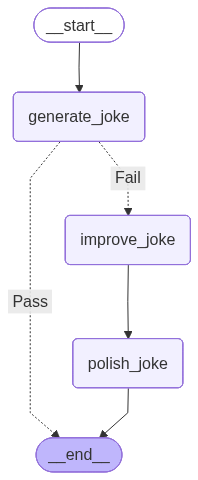

In [35]:
workflow = StateGraph(State)
# Ajout des noeuds
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)
# Connecter chaque noeud
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges("generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END})
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)
# Compiler
chain = workflow.compile()
#show workflow

display(Image(chain.get_graph().draw_mermaid_png()))

In [36]:
state = chain.invoke(State({"topic": "les chats", "joke":"", "improved_joke":"", "final_joke": ""}))

print("Initial Joke: ")
print(state["joke"])
print("\n--- ---\n")
if state["improved_joke"]:
    print("Improved joke")
    print(state["improved_joke"])
    print("\n--- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke")
    print(state["joke"])

Initial Joke: 
Voici quelques options, selon que tu préfères une blague basée sur les jeux de mots ou une observation :

### 😸 L'observation (le plus populaire)
Les chats sont des maîtres dans l'art de nous faire croire qu'ils t'aiment, juste le temps de s'installer pour une sieste parfaite... sur ton clavier.

***

### 😂 Le jeu de mots (plus léger)
Que dit un chat quand il a très faim ?
« Miaou-dée ! » 😼

***

### ✨ La courte blague Q&R
Pourquoi le chat est-il expulsé de la boulangerie ?
Parce qu'il ne cessait que de pétrir les croissants !

--- ---

Final joke
Voici quelques options, selon que tu préfères une blague basée sur les jeux de mots ou une observation :

### 😸 L'observation (le plus populaire)
Les chats sont des maîtres dans l'art de nous faire croire qu'ils t'aiment, juste le temps de s'installer pour une sieste parfaite... sur ton clavier.

***

### 😂 Le jeu de mots (plus léger)
Que dit un chat quand il a très faim ?
« Miaou-dée ! » 😼

***

### ✨ La courte blague Q&R
Pour

# Parallelization

- Example : à partir d'un topic, générer une blague, une histoire et un poème

Cas d'usage :
- Découper en sous-tâches et les exécuter en parallèle, afin d'améliorer la vitesse
- Exécuter des tâches plusieurs fois pour vérifier les différentes sorties

In [37]:
from typing_extensions import TypedDict, cast

class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

In [20]:
# Noeuds
def call_llm_1(state: State) -> State:
    """1er LLM pour generer la blague"""
    msg = llm.invoke(f"Ecris une blague sur {state["topic"]}")
    #state["joke"] = f"{msg.content}"
    return {"joke": msg.content}

def call_llm_2(state: State) -> State:
    """Deuxieme LLM pour generer une histoire"""
    msg = llm.invoke(f"Ecris une histoire sur {state["topic"]}")
    #state["story"] = f"{msg.content}"
    return {"story": msg.content}

def call_llm_3(state: State) -> State:
    """3eme LLM pour generer un poeme"""
    msg = llm.invoke(f"Ecris un poem sur {state["topic"]}")
    #state["poem"] = f"{msg.content}"
    return {"poem": msg.content}

def aggregator(state: State) -> State:
    """Combiner les blague, histoire et poem en une sortie"""
    combined = f"Voici une histoire, une blague et un poeme sur {state["topic"]} !\n\n"
    combined += f"STORY:\n{state["story"]}\n\n"
    combined += f"JOKE:\n{state["joke"]}\n\n"
    combined += f"POEM:\n{state["poem"]}\n\n"
    #state["combined_output"] = combined
    return {"combined_output": combined}

In [21]:
from langgraph.graph import END, START, StateGraph
# Construction des workflows
parallel_builder = StateGraph(State)
# Ajout des noeuds
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)
# Ajout des connexions des noeuds
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
# Compiler
parallel_workflow = parallel_builder.compile()
# Show Workflow
#display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

NameError: name 'State' is not defined

In [21]:
# Predict
state = parallel_workflow.invoke(State({
    "topic": "chats",
    "combined_output": "",
    "joke": "",
    "story": "",
    "poem": ""
}))

print(state["combined_output"])

Voici une histoire, une blague et un poeme sur chats !

STORY:
**Titre : Le Chuchoteur des Rues de Paris**

Dans le cœur palpitant de Paris, au bord du Seine, vivait un chat nommé Léo. Il n’était pas comme les autres chats : ses poils étaient d’un gris éclatant, et il portait souvent une petite souris collée à sa queue, comme s’il essayait de se faire passer pour quelque chose de plus grand que lui-même. Mais ce qui le distinguait vraiment, c’était son regard. Un regard qui semblait lire les pensées des humains autour de lui, même sans qu’on puisse comprendre pourquoi.

Un matin, alors que les premiers rayons du soleil filtraient par les rideaux, Léo se promena dans le quartier Latin. Il chassait une souris avec une précision surprenante, mais ce jour-là, quelque chose de différent attira son attention. Une femme, assise sur un banc, semblait perdue dans ses pensées. Léo s’approcha doucement, sans brusquer. Il murmura : *« Tu as l’air triste aujourd’hui, chatte ? »* La femme le regarda

In [22]:
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    fun_or_not: str

#structure pour la sortie du LLM
class Feedback(BaseModel):
    grade: Literal["Funny", "Not Funny"] = Field(..., description="Indique si la blague est drôle ou pas.")
    feedback: str = Field(..., description="Si la blague n'est pas drôle, donne un feedback sur comment l'améliorer.")


In [23]:
from typing import Literal

evaluator = llm.with_structured_output(Feedback)

In [24]:

def call_llm_generator(state: State):
    """Appel LLM pour générer une blague à partir du sujet."""
    if state["feedback"]:
        msg = llm.invoke(f"Ecris une blague sur {state['topic']} en tenant compte du feedback suivant : {state['feedback']}")

    else:
        msg = llm.invoke(f"Ecris une blague sur {state['topic']}")
    return {"joke": msg.content}

In [25]:

def call_llm_evaluator(state: State):
    """Appel LLM pour évaluer une blague qui a été générée."""
    grade = cast(Feedback, evaluator.invoke(f"Evalue la blague {state['joke']}"))
    print(f"Note: {grade.grade}, Feedback: {grade.feedback}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

In [27]:
def route_joke(state: State):
    """renvoyer ou terminer suivant le feedback de l'evaluator"""
    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "Not Funny":
        return "Rejected + Feedback"

In [30]:
#construction du workflow

optimizer_builder = StateGraph(State)
# Ajout des noeuds
optimizer_builder.add_node("llm_call_generator", call_llm_generator)
optimizer_builder.add_node("llm_call_evaluator", call_llm_evaluator)

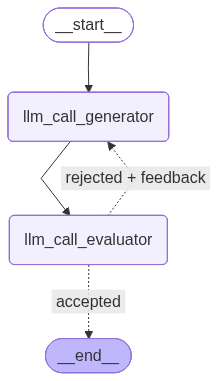

In [31]:
#ajouts des edges (liens noeuds)

optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
        "llm_call_evaluator", 
        route_joke,
            {
                               "accepted": END,
                                 "rejected + feedback": "llm_call_generator",
            }
                    ) 
# Compiler le workflow
optimizer_chain = optimizer_builder.compile()
#Afficher
display(Image(optimizer_chain.get_graph().draw_mermaid_png()))

In [ ]:
#generer la blague optimisée
state = optimizer_chain.invoke(State({"topic": "les chats", "joke":"", "feedback":"", "funny_or_not": ""}))

print("Blague finale:")
print(state["joke"])

In [9]:
from langchain.tools import tool


@tool
def multiply(a: int, b: int) -> int:
    """Multiplie a et b
    args:
        a: first int
        b: second int
   """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Additionne a et b
    args:
        a: first int
        b: second int
   """
    return a + b

@tool

def division(a: int, b: int) -> int:
    """Divise a par b
    args:
        a: first int
        b: second int
   """
    if b == 0:
        return "Error: Division by zero"
    return a / b

In [11]:
# augementer le llm avec les tools

tools = [add, multiply, division]
tools_bay_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [16]:
from langgraph.graph import MessagesState, StateGraph
from langchain.messages import SystemMessage, HumanMessage, ToolMessage

In [13]:
def llm_call(state: MessagesState):
    """LLM decide entre appeler un outil ou non"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="Tu es un assistant qui peut faire des calculs mathématiques qui réalise des calculs arithmétiques sur les données d'entree."
                    )
                ] + state["messages"]
            )
        ]
    }

# Edge conditionnel pour decider si le LLM continue le tool call ou renvoie le resultat

def should_continue(state: MessagesState):
    """decide si on contionue à appeler la bouccle d'appel de tool ou non"""
    messages = state["messages"]
    last_message = messages[-1]

    #si le llm fait un appel de tool realiser l'action 

    if last_message.tool_calls:
        return "tool_node"
    #sinon on stock et on return à l'utilisateur
    return END



In [22]:
from langgraph.prebuilt import ToolNode
from langgraph.graph import END, START, StateGraph

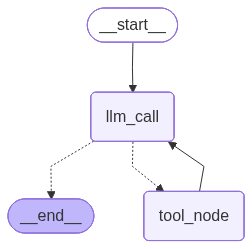

In [25]:
#Build workflow

agent_builder = StateGraph(MessagesState)
# Ajout des noeuds
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", ToolNode(tools))

#connexion noeuds
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)

agent_builder.add_edge("tool_node", "llm_call")
# Compiler le workflow
agent = agent_builder.compile()
#Afficher
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [38]:
#invoke 
messages = [HumanMessage(content="additionne 3 et 4")]
messages = agent.invoke({"message": messages})

for m in messages["messages"]:
    m.pretty_print()

BadRequestError: Error code: 400 - {'error': 'Model unloaded.'}